In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Dependencies

#connect to google drive!
!pip install nilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 13.7 MB/s eta 0:00:00


In [3]:
#Dependencies
import pandas as pd
import shutil
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import numpy as np

#if we resize
from PIL import Image

In [4]:
import nilearn.image as image
from nilearn.image import resample_to_img
import nilearn.plotting as plotting
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets

In [5]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

####Separate data

In [ ]:
def separate_data():
  #make directories
  os.makedirs("axial_images/control", exist_ok=True)
  os.makedirs("coronal_images/control", exist_ok=True)
  os.makedirs("sagittal_images/control", exist_ok=True)
  os.makedirs("axial_images/ASD", exist_ok=True)
  os.makedirs("coronal_images/ASD", exist_ok=True)
  os.makedirs("sagittal_images/ASD", exist_ok=True)


  #sort axial images
  for img in os.listdir("axial_images"):
    if "ASD" in img and "png" in img:
      file_path = "axial_images/" + img
      dest_path = "axial_images/ASD/" + img
      shutil.move(file_path, dest_path)
    if "CONTROL" in img and "png" in img:
      file_path = "axial_images/" + img
      dest_path = "axial_images/control/" + img
      shutil.move(file_path, dest_path)
  #sort coronal images
  for img in os.listdir("coronal_images"):
    if "ASD" in img and "png" in img:
      file_path = "coronal_images/" + img
      dest_path = "coronal_images/ASD/" + img
      shutil.move(file_path, dest_path)
    if "CONTROL" in img and "png" in img:
      file_path = "coronal_images/" + img
      dest_path = "coronal_images/control/" + img
      shutil.move(file_path, dest_path)
  #sort sagittal images
  for img in os.listdir("sagittal_images"):
    if "ASD" in img and "png" in img:
      file_path = "sagittal_images/" + img
      dest_path = "sagittal_images/ASD/" + img
      shutil.move(file_path, dest_path)
    if "CONTROL" in img and "png" in img:
      file_path = "sagittal_images/" + img
      dest_path = "sagittal_images/control/" + img
      shutil.move(file_path, dest_path)




####Normalizing


In [ ]:
#NORMALIZING - showing MNI152 template
# Load the MNI152 template
mni152_template = datasets.load_mni152_template()
plotting.plot_img(mni152_template, title='MNI152 Template')
plotting.show()
print(mni152_template.shape) #197 233 189


# NORMALIZE
sites = ['CALTECH', 'KKI','OLIN', 'MAX_MUN', 'CMU', 'NYU', 'OHSU', 'SDSU', 'SBL', 'STANFORD', 'TRINITY,' 'UCLA_1', 'UCLA_2', 'LEUVEN_1', 'LEUVEN_2', 'UM_1', 'UM_2', 'PITT', 'USM', 'YALE' ]
items =  os.listdir("/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_data")
items_sorted = sorted(items)
for site in sites:
  print("STARTING SITE: ", site)
  for img in items_sorted:
    if ".nii.gz" in img and site in img:
      image_path = "/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_data/" + img
      mprage_img = nib.load(image_path)
      print(mprage_img.shape)
      plotting.plot_img(mprage_img, title='Original mprage image')
      plotting.show()

      normalized_mprage_image = resample_to_img(source_img=mprage_img, target_img=mni152_template)
      plotting.plot_img(normalized_mprage_image, title="Normalized mprage image with nearest interpolation")
      print(normalized_mprage_image.shape)
      plotting.show()



In [ ]:
from nilearn import datasets, image, plotting
from nilearn.image import resample_to_img
import matplotlib.pyplot as plt
import os

items =  os.listdir("/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_data")
items_sorted = sorted(items)
sites = ['NYU', 'OHSU', 'SDSU', 'SBL', 'STANFORD', 'TRINITY,' 'UCLA_1', 'UCLA_2', 'LEUVEN_1', 'LEUVEN_2', 'UM_1', 'UM_2', 'PITT', 'USM', 'YALE' ]

for site in sites:
  print("STARTING SITE: ", site)
  for img in items_sorted:
    if ".nii.gz" in img and site in img:
      if img > "NYU_51036_CONTROL_mprage.nii.gz":
        image_name = img[:-7]
        print(image_name)
        image_path = "/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_data/" + img
        mprage_img = image.load_img(image_path)
        # Get the data and affine
        # Iterate through each slice in the axial plane
        for z in range(0, 100, 10):
            # Define the output filename
            output_filename = f'/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_data/axial_slices_{z}/{image_name}_axial_{z}.png'
            # Plot and save the slice
            display = plotting.plot_anat(mprage_img, display_mode='z', cut_coords=[z], title=f'Axial Slice {z}', annotate=False)
            display.savefig(output_filename)
            display.close()




####Visualize some examples - USE!!

In [ ]:
import nibabel as nib

# Load the NIfTI file
nii_file = '/content/drive/MyDrive/UoM Autism Summer 2024/mprage_asd/LEUVEN_1_50686_ASD_mprage.nii.gz'
img = nib.load(nii_file)

# Get the image data
data = img.get_fdata()

# Get the affine transformation matrix
affine = img.affine

# Get the dimensions of the image
dimensions = data.shape

# Get the voxel sizes (in mm)
voxel_sizes = img.header.get_zooms()

# Calculate the z-coordinate range
num_slices = dimensions[2]  # Number of slices in the z-dimension
slice_thickness = voxel_sizes[2]  # Voxel size in the z-dimension

# Assuming the origin is at the center of the first voxel
z_start = 0
z_end = z_start + (num_slices - 1) * slice_thickness

print(f"Z-coordinate range: {z_start} mm to {z_end} mm")


In [13]:
import nibabel as nib
import numpy as np




def getReal(nii_file, z):
  img = nib.load(nii_file)

  # Get the affine transformation matrix
  affine = img.affine

  # Get the number of slices in the z-dimension
  num_slices = img.shape[2]

  # Function to convert voxel indices to real-world coordinates
  def voxel_to_world(affine, voxel_indices):
      voxel_indices = np.append(voxel_indices, 1)  # Convert to homogeneous coordinates
      world_coords = affine @ voxel_indices
      return world_coords[:3]

  voxel_indices = [0, 0, z]  # Assuming we want the coordinate at the center of the slice
  world_coords = voxel_to_world(affine, voxel_indices)
  print(f"Slice {z}: z-coordinate = {world_coords[2]:.2f} mm")
  print(world_coords[2])
  return world_coords[2]

getReal("/content/drive/MyDrive/UoM Autism Summer 2024/mprage_control/UCLA_1_51262_CONTROL_mprage.nii.gz", -30)
getReal("/content/drive/MyDrive/UoM Autism Summer 2024/mprage_asd/NYU_51001_ASD_mprage.nii.gz", -30)

Slice -30: z-coordinate = -153.55 mm
-153.54924738407135
Slice -30: z-coordinate = -175.07 mm
-175.07229614257812


-175.07229614257812

In [7]:
import pandas as pd
df = pd.read_csv('Z slices Mprage.csv')


# Loop through each row
for index, row in df.iterrows():
    if index >= 847 and index < len(df):
        name = row['Name']
        if 'CONTROL' in name:
            image_path = f"/content/drive/MyDrive/UoM Autism Summer 2024/mprage_control/{name[:-4]}.nii.gz"
            print(image_path)
            # Update the DataFrame directly using loc
            df.loc[index, 'start z real coord'] = int(getReal(image_path, row['start z']))
        else:
          image_path = f"/content/drive/MyDrive/UoM Autism Summer 2024/mprage_asd/{name[:-4]}.nii.gz"
          print(image_path)
          # Update the DataFrame directly using loc
          df.loc[index, 'start z real coord'] = int(getReal(image_path, row['start z']))

# Save the updated DataFrame to CSV
df.to_csv("Z slices modified.csv", index=False)


/content/drive/MyDrive/UoM Autism Summer 2024/mprage_control/UM_1_50333_CONTROL_mprage.nii.gz
Slice -40: z-coordinate = -126.70 mm
-126.69999599456787
/content/drive/MyDrive/UoM Autism Summer 2024/mprage_control/UM_1_50334_CONTROL_mprage.nii.gz
Slice -40: z-coordinate = -126.70 mm
-126.69999599456787
/content/drive/MyDrive/UoM Autism Summer 2024/mprage_control/UM_1_50335_CONTROL_mprage.nii.gz
Slice -30: z-coordinate = -112.70 mm
-112.69999623298645
/content/drive/MyDrive/UoM Autism Summer 2024/mprage_control/UM_1_50336_CONTROL_mprage.nii.gz
Slice -40: z-coordinate = -126.70 mm
-126.69999599456787
/content/drive/MyDrive/UoM Autism Summer 2024/mprage_control/UM_1_50337_CONTROL_mprage.nii.gz
Slice -50: z-coordinate = -133.80 mm
-133.8000054359436
/content/drive/MyDrive/UoM Autism Summer 2024/mprage_control/UM_1_50338_CONTROL_mprage.nii.gz
Slice -30: z-coordinate = -112.70 mm
-112.69999623298645
/content/drive/MyDrive/UoM Autism Summer 2024/mprage_control/UM_1_50339_CONTROL_mprage.nii.gz
S

In [ ]:
dir = "/content/drive/MyDrive/UoM Autism Summer 2024/mprage_asd"
site = "LEUVEN_1"
items = os.listdir(dir)
items = sorted(items)


def inspectSite(img):
  print(img)
  image_path = "/content/drive/MyDrive/UoM Autism Summer 2024/mprage_asd/" + img
  mprage_img = image.load_img(image_path)
  img_data = mprage_img.get_fdata()
  print(img_data.shape)

  for z in range(-187, 100, 10):
      display = plotting.plot_anat(mprage_img, display_mode='z', cut_coords=[z], title=f'Axial Slice {z}', annotate=False)
      display.savefig(output_filename)
      plt.show()
      display.close()
    #display = plotting.plot_anat(mprage_img, display_mode='z', cut_coords=[z], title=f'Axial Slice {z}', annotate=False)
    #plt.show()
   # display.close()

inspectSite("LEUVEN_1_50686_ASD_mprage.nii.gz")

#display = plotting.plot_anat(mprage_img, display_mode='z')



['CALTECH_51456_ASD_mprage_axial_60.png', 'CALTECH_51457_ASD_mprage_axial_60.png', 'CALTECH_51458_ASD_mprage_axial_60.png', 'CALTECH_51459_ASD_mprage_axial_60.png', 'CALTECH_51460_ASD_mprage_axial_60.png', 'KKI_50772_CONTROL_mprage_axial_60.png', 'KKI_50773_CONTROL_mprage_axial_60.png', 'KKI_50774_CONTROL_mprage_axial_60.png', 'KKI_50775_CONTROL_mprage_axial_60.png', 'KKI_50776_CONTROL_mprage_axial_60.png', 'OLIN_50102_CONTROL_mprage_axial_60.png', 'OLIN_50103_CONTROL_mprage_axial_60.png', 'OLIN_50104_CONTROL_mprage_axial_60.png', 'OLIN_50105_CONTROL_mprage_axial_60.png', 'OLIN_50106_CONTROL_mprage_axial_60.png', 'MAX_MUN_51318_ASD_mprage_axial_60.png', 'MAX_MUN_51319_ASD_mprage_axial_60.png', 'MAX_MUN_51320_ASD_mprage_axial_60.png', 'MAX_MUN_51321_ASD_mprage_axial_60.png', 'MAX_MUN_51322_ASD_mprage_axial_60.png', 'CMU_50642_ASD_mprage_axial_60.png', 'CMU_50643_ASD_mprage_axial_60.png', 'CMU_50644_ASD_mprage_axial_60.png', 'CMU_50645_ASD_mprage_axial_60.png', 'CMU_50646_ASD_mprage_axia

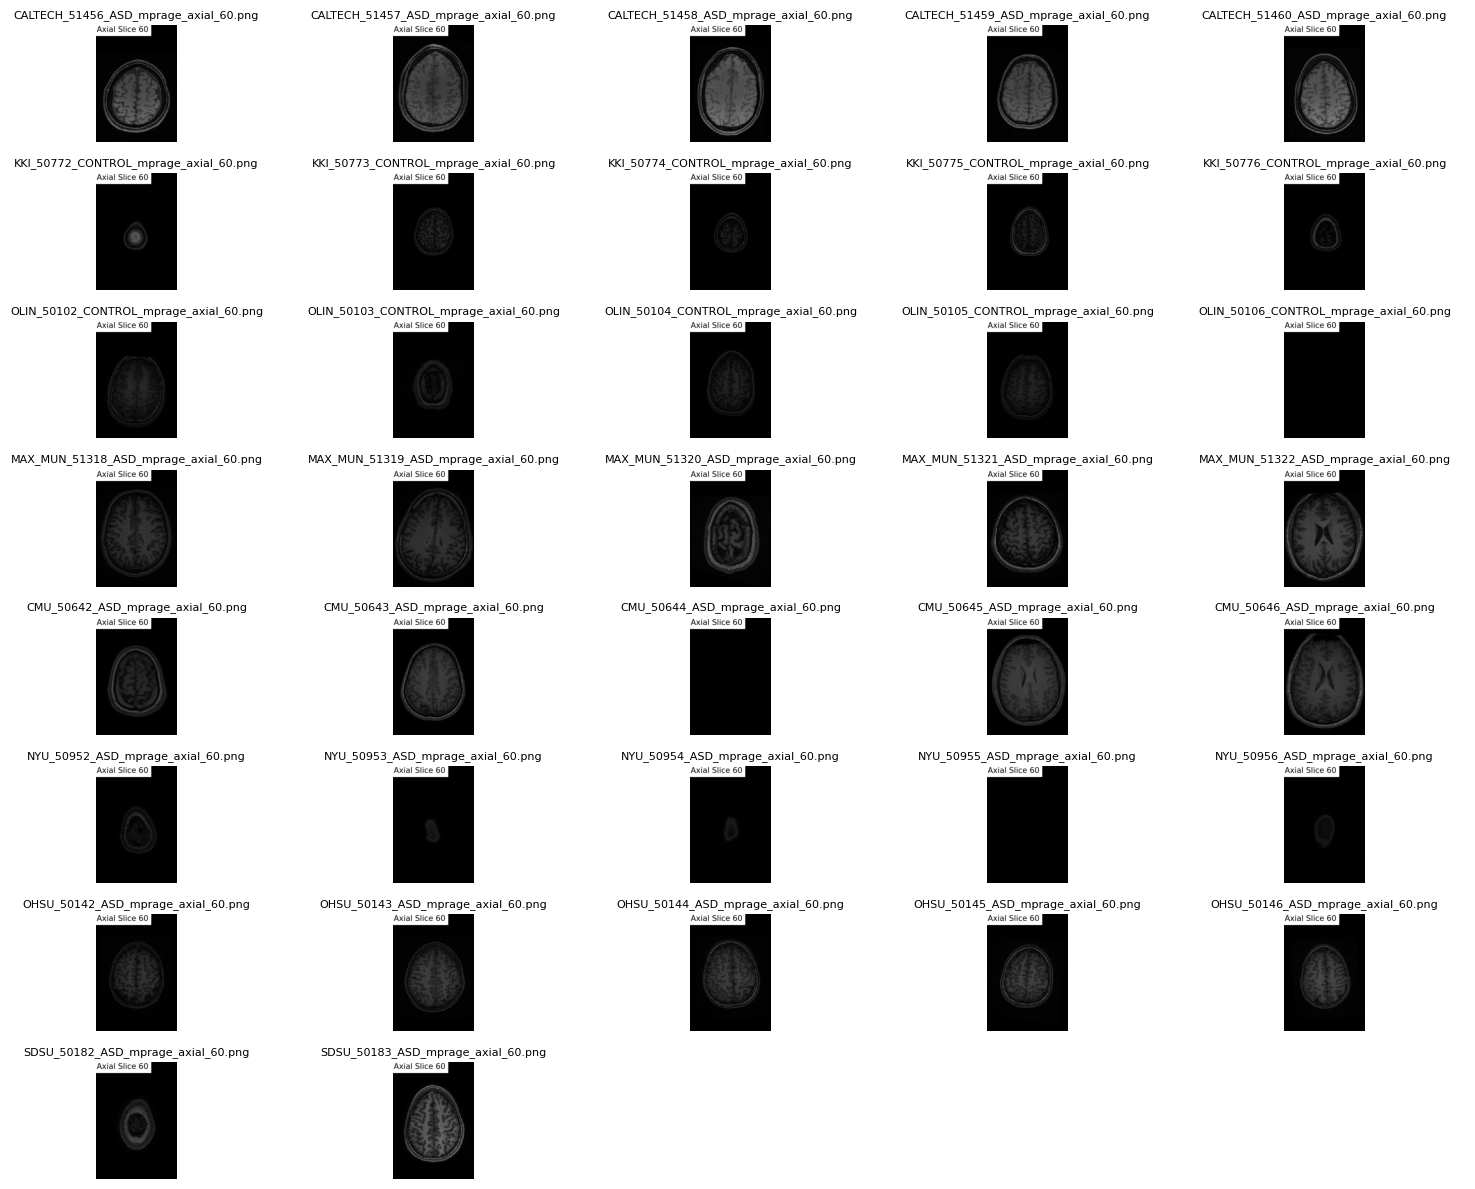

In [43]:
dir = "/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_data/axial_slices_0"

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def plot_images_in_directory(directory, images_per_row=5):
    #Get files
    files = [f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
    files = sorted(files)
    temp_image_files = [f for f in files if f.lower().endswith(('.png'))]
    image_files = []
    sites = ['CALTECH', 'KKI','OLIN', 'MAX_MUN', 'CMU', 'NYU', 'OHSU', 'SDSU', 'SBL', 'STANFORD', 'TRINITY,' 'UCLA_1', 'UCLA_2', 'LEUVEN_1', 'LEUVEN_2', 'UM_1', 'UM_2', 'PITT', 'USM', 'YALE' ]
    for site in sites:
      count = 0
      for img in temp_image_files:
        if site in img and count <5:
          image_files.append(img)
          count+=1
    print(image_files )

    num_images = len(image_files)

    # Create plots
    num_rows = (num_images // images_per_row) + (num_images % images_per_row > 0)
    fig, axes = plt.subplots(num_rows, images_per_row, figsize=(15, num_rows * 1.5))
    if num_rows > 1:
        axes = axes.flatten()

    #Loop through images
    for i, image_file in enumerate(image_files):
        # Load the image
        img = mpimg.imread(os.path.join(directory, image_file))
        # Display the image
        axes[i].imshow(img)
        # Set the title as the filename
        axes[i].set_title(image_file, fontsize=8)
        # Remove axis labels
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

# Use the function
plot_images_in_directory('/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_data/axial_slices_60')




### Model:

In [5]:
#dependencies
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.model_selection import train_test_split
import numpy as np
import os
from PIL import Image

import pandas as pd
import shutil
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

#if we resize
from PIL import Image

In [ ]:
def getImageNames(directory):
  images = []
  for filename in os.listdir(directory):
        if filename.endswith(".png"):
          path = directory + "/" + filename
          images.append(path)
  return np.array(images)

def getSets(control_dir, autistic_dir):
  X_control = getImageNames(control_dir)
  X_autistic = getImageNames(autistic_dir)
  # Split control data into training and validation sets
  X_train_control, X_test_control = train_test_split(X_control, test_size=0.2, random_state=42)
  X_train_control, X_val_control = train_test_split(X_train_control, test_size=0.2, random_state=42)
  X_train_ASD_not_to_use, X_test_ASD = train_test_split(X_autistic, test_size=0.2, random_state=42)
  print("X_train_control of size: ", X_train_control.shape)
  print("X_val_control of size: ", X_val_control.shape)
  print("X_test_control of size: ", X_test_control.shape)
  print("X_test_ASD of size: ", X_test_ASD.shape)
  return X_train_control, X_val_control, X_test_control, X_test_ASD

#Visualize sets - just to see what data looks like

def visualizeData(set, setName):
  print("Visualizing set: ", setName)
  fig, axes = plt.subplots(1, len(set), figsize=(15, 3))
  for i, filename in enumerate(set):
      img = Image.open(filename)
      axes[i].imshow(img)
      axes[i].axis('off')

  plt.tight_layout()
  plt.show()

def load_and_preprocess_images(set):
    images = []
    for filename in set:
      img = load_img(filename)
      img = np.array(img) / 255.0
      images.append(img)
    return np.array(images)
# Function to plot original, reconstructed, and subtraction images
def plot_images(original, reconstructed, title):
    fig, axes = plt.subplots(3, len(original), figsize=(15, 6))

    # Plot original images
    for i in range(len(original)):
        axes[0, i].imshow(original[i], cmap='gray')
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')

    # Plot reconstructed images
    for i in range(len(reconstructed)):
        axes[1, i].imshow(reconstructed[i], cmap='gray')
        axes[1, i].set_title('Reconstructed')
        axes[1, i].axis('off')

    # Plot subtraction (difference) images
    for i in range(len(original)):
        subtracted_img = np.abs(original[i] - reconstructed[i])
        axes[2, i].imshow(subtracted_img, cmap='gray')
        axes[2, i].set_title('Difference')
        axes[2, i].axis('off')

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_image_differences(image_1_path, image_2_path):
  # Load images
  img1 = Image.open(image_1_path)
  img2 = Image.open(image_1_path)

  # Convert images to numpy arrays and subtract
  img1_array = np.array(img1)
  img2_array = np.array(img2)
  subtracted_img = np.abs(img1_array - img2_array)

  # Plot original images and subtraction result
  fig, axes = plt.subplots(1, 3, figsize=(12, 4))

  # Plot first image
  axes[0].imshow(img1_array, cmap='gray')
  axes[0].set_title('Image 1')
  axes[0].axis('off')

  # Plot second image
  axes[1].imshow(img2_array, cmap='gray')
  axes[1].set_title('Image 2')
  axes[1].axis('off')

  # Plot subtraction result
  axes[2].imshow(subtracted_img, cmap='gray')
  axes[2].set_title('Subtraction Result')
  axes[2].axis('off')

  plt.tight_layout()
  plt.show()

In [ ]:
from tensorflow.keras.layers import Input, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

def autoencoder(X_train_control, X_val_control, X_test_control, X_test_ASD):
    input_img = Input(shape=(256, 256, 3))  # adjust if we resize

    # Encoder
    encoded = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(input_img)
    encoded = BatchNormalization()(encoded)
    encoded = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(encoded)
    encoded = BatchNormalization()(encoded)

    # Decoder
    decoded = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(encoded)
    decoded = BatchNormalization()(decoded)
    decoded = Dense(3, activation='sigmoid', kernel_regularizer=l2(0.01))(decoded)

    # Autoencoder model
    stacked_AE = Model(input_img, decoded)

    # Compile
    stacked_AE.compile(optimizer='adam', loss='mse')


    #add early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    #save history
    history = stacked_AE.fit(X_train_control, X_train_control, epochs=100,
                         batch_size=32, validation_data=(X_val_control, X_val_control),
                         callbacks=[early_stopping])

    # Plot model history
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper right')
    plt.show()

    # Predict on test data
    reconstructed_control = stacked_AE.predict(X_test_control)
    reconstructed_ASD = stacked_AE.predict(X_test_ASD)

    # Calculate MSE for control and ASD MRIs
    mse_control = np.mean(np.square(reconstructed_control - X_test_control))
    mse_ASD = np.mean(np.square(reconstructed_ASD - X_test_ASD))

    print(f"MSE on test set (control MRIs): {mse_control}")
    print(f"MSE on test set (ASD MRIs): {mse_ASD}")

    # Calculate average images
    avg_reconstructed_control = np.mean(reconstructed_control, axis=0)
    avg_reconstructed_ASD = np.mean(reconstructed_ASD, axis=0)

    # Plot and save average images
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(avg_reconstructed_control)
    plt.title('Average Reconstructed Control')
    plt.axis('off')
    plt.savefig('avg_reconstructed_control.png')

    plt.subplot(1, 2, 2)
    plt.imshow(avg_reconstructed_ASD)
    plt.title('Average Reconstructed ASD')
    plt.axis('off')
    plt.savefig('avg_reconstructed_ASD.png')

    plt.show()

    # Calculate difference images
    diff_control = np.abs(X_test_control - reconstructed_control)
    diff_ASD = np.abs(X_test_ASD - reconstructed_ASD)

    # Calculate average difference images
    avg_diff_control = np.mean(diff_control, axis=0)
    avg_diff_ASD = np.mean(diff_ASD, axis=0)

    # Plot and save average difference images
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(avg_diff_control)
    plt.title('Average Difference Control')
    plt.axis('off')
    plt.savefig('avg_diff_control.png')

    plt.subplot(1, 2, 2)
    plt.imshow(avg_diff_ASD)
    plt.title('Average Difference ASD')
    plt.axis('off')
    plt.savefig('avg_diff_ASD.png')

    plt.show()

    # VISUALIZE RECONSTRUCTIONS
    # Select a few examples from X_test_control and X_test_ASD
    num_examples = 5  # Number of examples to visualize
    examples_control = X_test_control[:num_examples]
    examples_ASD = X_test_ASD[:num_examples]

    # Plot examples for control MRIs
    plot_images(examples_control, reconstructed_control[:num_examples], title='Control MRI Reconstruction')

    # Plot examples for ASD MRIs
    plot_images(examples_ASD, reconstructed_ASD[:num_examples], title='ASD MRI Reconstruction')

In [ ]:

def runModel(view):
  control_dir = "/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_axial_images_resized/control"
  autistic_dir = "/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_axial_images_resized/ASD"
  X_train_control, X_val_control, X_test_control, X_test_ASD = getSets(control_dir, autistic_dir)

  #visualizeData(X_test_control, "X_test_control")
  #visualizeData(X_test_ASD, "X_test_ASD")

  #print("Plotting an example difference between control and ASD")
  #plot_image_differences(X_test_control[0], X_test_ASD[0])

  X_train_control = load_and_preprocess_images(X_train_control)
  X_val_control = load_and_preprocess_images(X_val_control)
  X_test_ASD = load_and_preprocess_images(X_test_ASD)
  X_test_control = load_and_preprocess_images(X_test_control)
  print("X_train_control images shape: ", X_train_control.shape)
  print("X_val_control images shape: ", X_val_control.shape)
  print("X_test_control images shape: ", X_test_control.shape)
  print("X_test_ASD images shape: ", X_test_ASD.shape)

  autoencoder(X_train_control, X_val_control, X_test_control, X_test_ASD)


runModel("axial")

X_train_control of size:  (366,)
X_val_control of size:  (92,)
X_test_control of size:  (115,)
X_test_ASD of size:  (108,)


X_train_control of size:  (366,)
X_val_control of size:  (92,)
X_test_control of size:  (115,)
X_test_ASD of size:  (108,)
X_train_control images shape:  (366, 256, 256, 3)
X_val_control images shape:  (92, 256, 256, 3)
X_test_control images shape:  (115, 256, 256, 3)
X_test_ASD images shape:  (108, 256, 256, 3)
Epoch 1/20
12/12 [==============================] - 58s 5s/step - loss: 0.1482 - val_loss: 0.1263
Epoch 2/20
12/12 [==============================] - 53s 4s/step - loss: 0.1112 - val_loss: 0.0923
Epoch 3/20
12/12 [==============================] - 58s 5s/step - loss: 0.0805 - val_loss: 0.0684
Epoch 4/20
12/12 [==============================] - 52s 4s/step - loss: 0.0604 - val_loss: 0.0509
Epoch 5/20
12/12 [==============================] - 55s 5s/step - loss: 0.0432 - val_loss: 0.0350
Epoch 6/20
12/12 [==============================] - 54s 5s/step - loss: 0.0293 - val_loss: 0.0235
Epoch 7/20
12/12 [==============================] - 63s 5s/step - loss: 0.0188 - val_loss: 0.0143


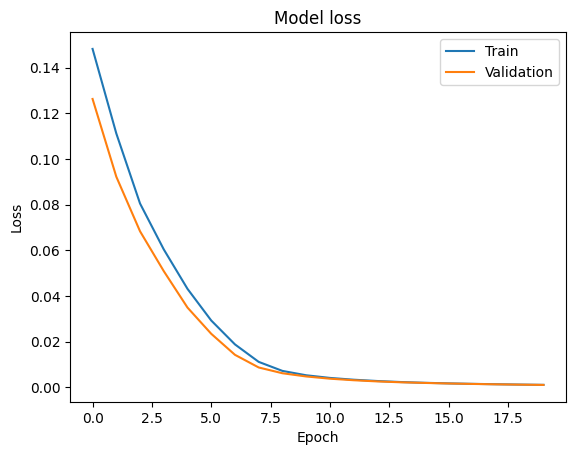

4/4 [==============================] - 5s 1s/step
MSE on test set (control MRIs): 0.0010558621368723224
MSE on test set (ASD MRIs): 0.0010787708130191738


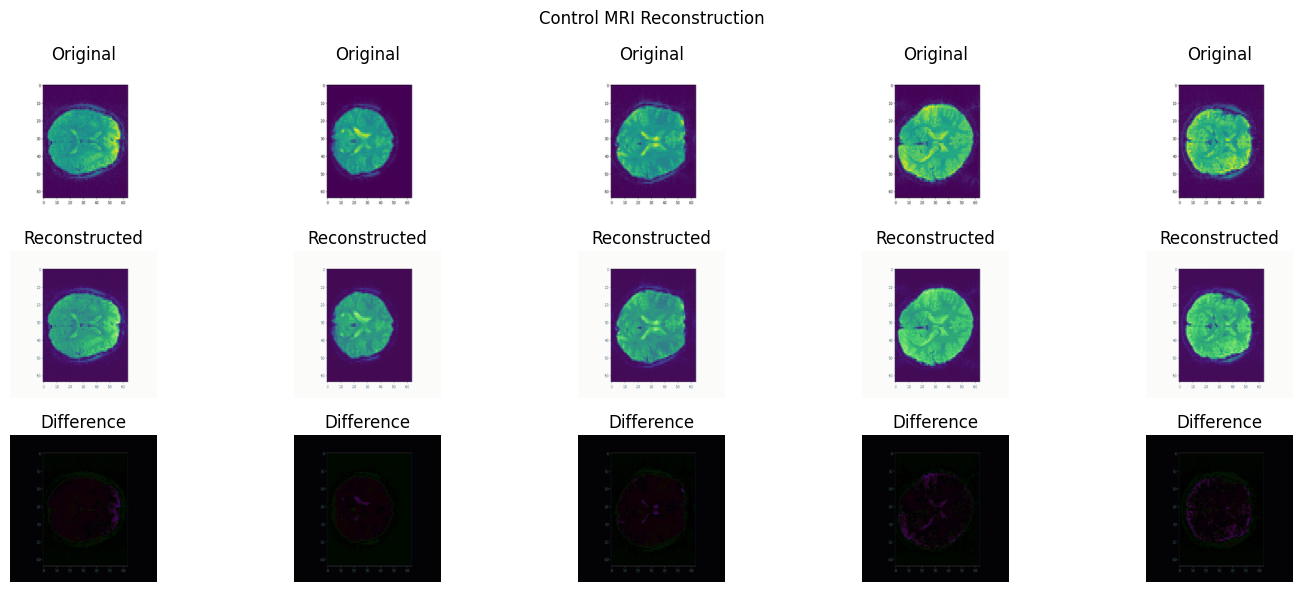

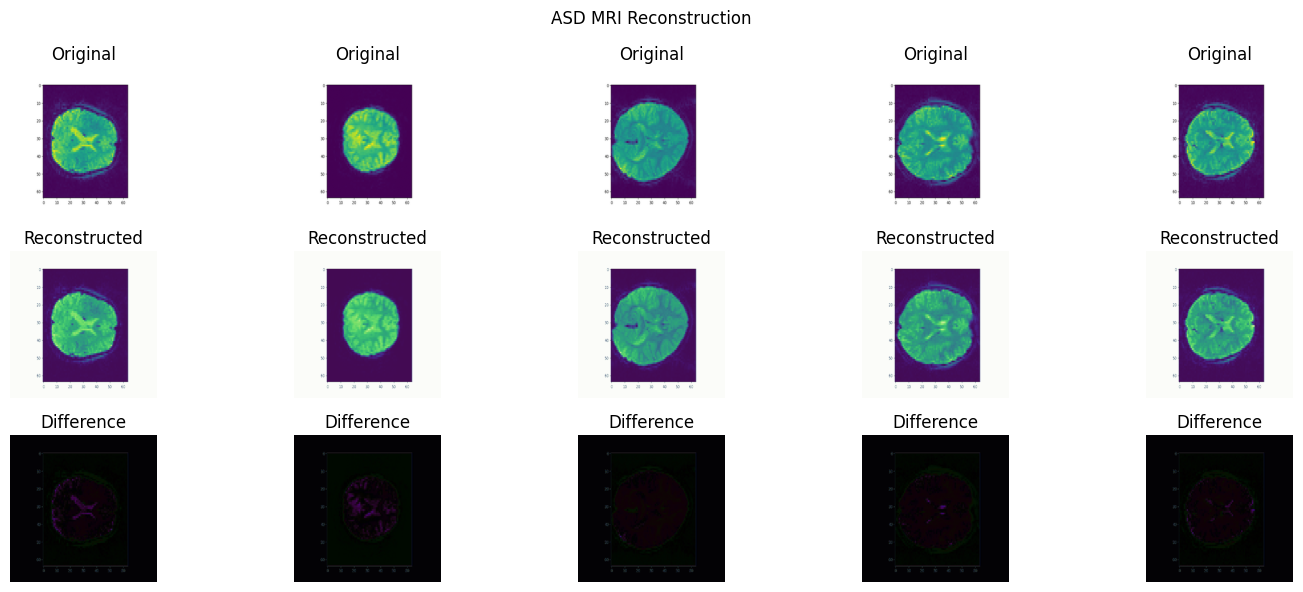

In [ ]:
runModel("sagittal")

X_train_control of size:  (366,)
X_val_control of size:  (92,)
X_test_control of size:  (115,)
X_test_ASD of size:  (108,)
X_train_control images shape:  (366, 256, 256, 3)
X_val_control images shape:  (92, 256, 256, 3)
X_test_control images shape:  (115, 256, 256, 3)
X_test_ASD images shape:  (108, 256, 256, 3)
Epoch 1/20
12/12 [==============================] - 56s 5s/step - loss: 0.1521 - val_loss: 0.1288
Epoch 2/20
12/12 [==============================] - 54s 4s/step - loss: 0.1143 - val_loss: 0.0965
Epoch 3/20
12/12 [==============================] - 54s 5s/step - loss: 0.0859 - val_loss: 0.0746
Epoch 4/20
12/12 [==============================] - 54s 4s/step - loss: 0.0673 - val_loss: 0.0599
Epoch 5/20
12/12 [==============================] - 59s 5s/step - loss: 0.0533 - val_loss: 0.0468
Epoch 6/20
12/12 [==============================] - 54s 5s/step - loss: 0.0411 - val_loss: 0.0356
Epoch 7/20
12/12 [==============================] - 56s 5s/step - loss: 0.0304 - val_loss: 0.0255


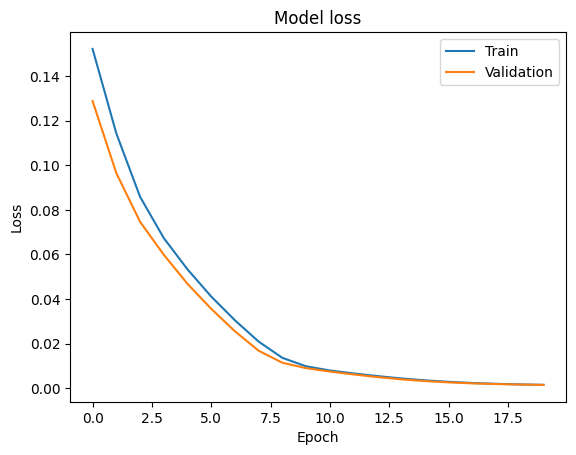

4/4 [==============================] - 7s 2s/step
MSE on test set (control MRIs): 0.0014313404129670585
MSE on test set (ASD MRIs): 0.0014675910194830936


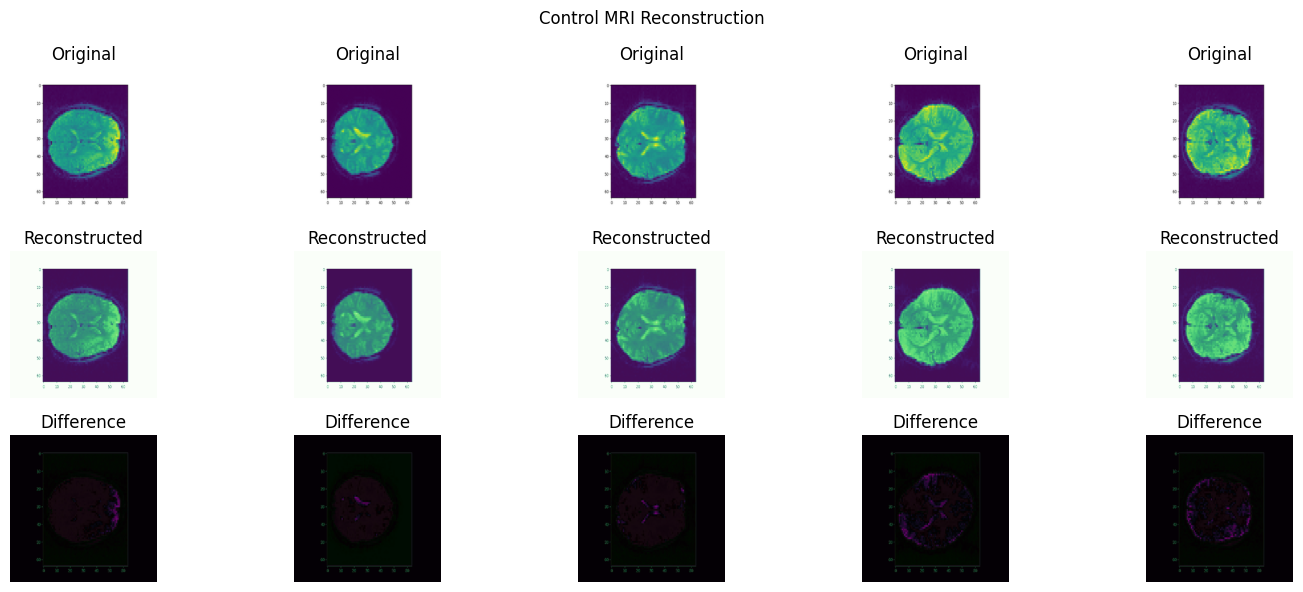

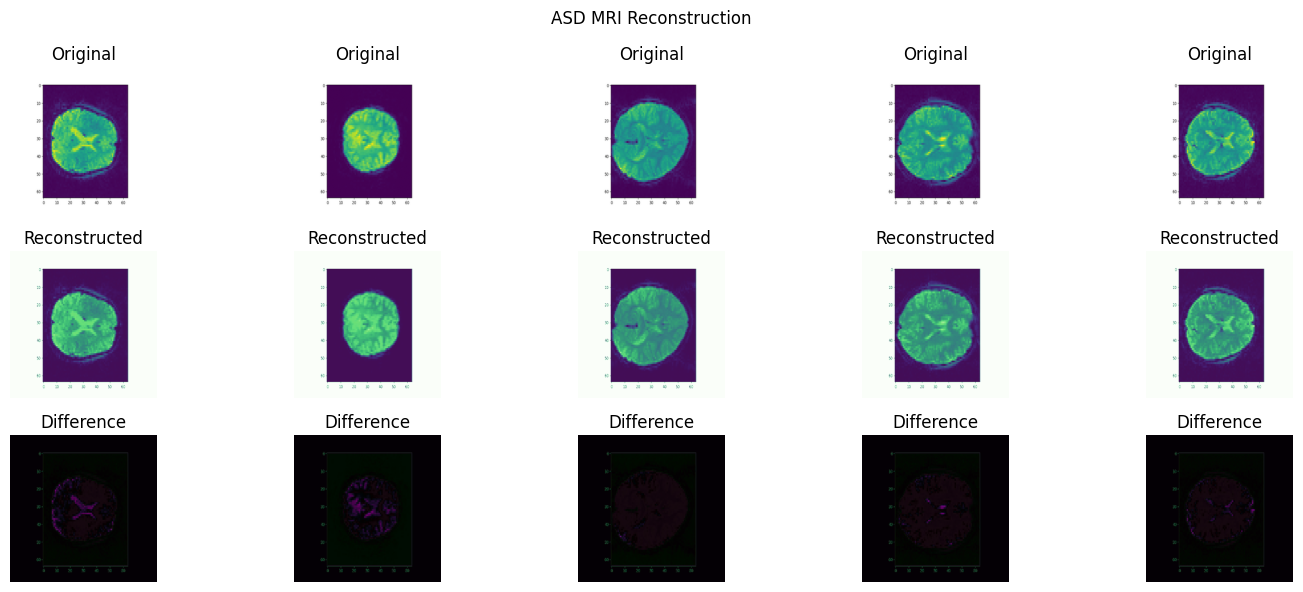

In [ ]:
runModel("coronal")

Questions:
- Look at image subtraction
- Should I try working with nii.gz instead of png?
- or mprage data?
- Resizing???


Need bigger dataset STILL
Need to do model history still
